# importing the first data set

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import tree 

In [6]:
!pip install requests

Defaulting to user installation because normal site-packages is not writeable


In [7]:
import requests

In [9]:
API_KEY = "54RcwnW0CoIx1ylNtSDUgeAkwEoOPrnBnPNXIAsi"
url = f"https://api.eia.gov/v2/crude-oil-imports/data/?frequency=monthly&data[0]=quantity&sort[0][column]=period&sort[0][direction]=desc&offset=0&length=5000&api_key={API_KEY}"

In [11]:
response = requests.get(url)

In [12]:
response.json()

{'warnings': [{'warning': 'incomplete return',
   'description': 'The API can only return 5000 rows in JSON format.  Please consider constraining your request with facet, start, or end, or using offset to paginate results.'}],
 'response': {'total': '546784',
  'dateFormat': 'YYYY-MM',
  'frequency': 'monthly',
  'data': [{'period': '2026-01',
    'originId': 'CTY_AG',
    'originName': 'Algeria',
    'originType': 'CTY',
    'originTypeName': 'Country',
    'destinationId': 'PP_1',
    'destinationName': 'PADD1 (East Coast)',
    'destinationType': 'PP',
    'destinationTypeName': 'Port PADD',
    'gradeId': 'LSW',
    'gradeName': 'Light Sweet',
    'quantity': '658',
    'quantity-units': 'thousand barrels'},
   {'period': '2026-01',
    'originId': 'CTY_AG',
    'originName': 'Algeria',
    'originType': 'CTY',
    'originTypeName': 'Country',
    'destinationId': 'PS_NJ',
    'destinationName': 'New Jersey',
    'destinationType': 'PS',
    'destinationTypeName': 'Port State',
   

In [13]:
data = response.json()

In [16]:
df = pd.DataFrame(data['response']['data'])

In [17]:
df.head()

,period,originId,originName,originType,originTypeName,destinationId,destinationName,destinationType,destinationTypeName,gradeId,gradeName,quantity,quantity-units
0,2026-01,CTY_AG,Algeria,CTY,Country,PP_1,PADD1 (East Coast),PP,Port PADD,LSW,Light Sweet,658,thousand barrels
1,2026-01,CTY_AG,Algeria,CTY,Country,PS_NJ,New Jersey,PS,Port State,LSW,Light Sweet,658,thousand barrels
2,2026-01,CTY_AG,Algeria,CTY,Country,PT_1003,"Newark, NJ",PT,Port,LSW,Light Sweet,658,thousand barrels
3,2026-01,CTY_AG,Algeria,CTY,Country,RF_335,PHILLIPS 66 CO / BAYWAY / NJ,RF,Refinery,LSW,Light Sweet,658,thousand barrels
4,2026-01,CTY_AG,Algeria,CTY,Country,RP_1,PADD1 (East Coast),RP,Refinery PADD,LSW,Light Sweet,658,thousand barrels


### defining each column

In [18]:
column_meanings = {
    'period': 'The month and year of the data (YYYY-MM format)',
    'originId': 'Unique identifier for the country of origin',
    'originName': 'Name of the country exporting crude oil',
    'originType': 'Type classification of the origin (CTY for Country, OPN for OPEC/non-OPEC)',
    'originTypeName': 'Full name of the origin type',
    'destinationId': 'Unique identifier for the destination (port, refinery, or PADD)',
    'destinationName': 'Name of the destination facility or region',
    'destinationType': 'Type of destination (PP for Port PADD, PS for Port State, PT for Port, RF for Refinery, RP for Refinery PADD)',
    'destinationTypeName': 'Full description of the destination type',
    'gradeId': 'Code for the crude oil grade (LSW, LSO, MED, HSO)',
    'gradeName': 'Full name of the crude oil grade (Light Sweet, Light Sour, Medium, Heavy Sour)',
    'quantity': 'Amount of crude oil imported (numerical value)',
    'quantity-units': 'Unit of measurement for quantity (thousand barrels)'
}

for column, meaning in column_meanings.items():
    print(f"{column}: {meaning}")

period: The month and year of the data (YYYY-MM format)
originId: Unique identifier for the country of origin
originName: Name of the country exporting crude oil
originType: Type classification of the origin (CTY for Country, OPN for OPEC/non-OPEC)
originTypeName: Full name of the origin type
destinationId: Unique identifier for the destination (port, refinery, or PADD)
destinationName: Name of the destination facility or region
destinationType: Type of destination (PP for Port PADD, PS for Port State, PT for Port, RF for Refinery, RP for Refinery PADD)
destinationTypeName: Full description of the destination type
gradeId: Code for the crude oil grade (LSW, LSO, MED, HSO)
gradeName: Full name of the crude oil grade (Light Sweet, Light Sour, Medium, Heavy Sour)
quantity: Amount of crude oil imported (numerical value)
quantity-units: Unit of measurement for quantity (thousand barrels)


In [20]:
# Convert quantity to numeric if not already done
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')

# Compute total imports by country
imports_by_country = df.groupby('originName')['quantity'].sum().sort_values(ascending=False)

# Display top importing countries
print("Top importing countries:")
print(imports_by_country.head(10))

Top importing countries:
originName
Non-OPEC           2927207
World              2794659
Canada             2556393
Canada (Region)    1796536
Other Americas      602504
OPEC                410858
Middle East         257439
Mexico              211267
Saudi Arabia        194278
Guyana              163660
Name: quantity, dtype: int64


## adding the second data set

In [23]:
df_2 = pd.read_csv("final_project_dataset.csv")

In [24]:
df_2.head()

,Date;Spot Prices;Value;duoarea;area-name;product;product-name;process;process-name;series
0,2013-03-22;WTI Spot Price (U.S. Dollars per Ba...
1,2013-03-22;Brent Spot Price (U.S. Dollars per ...
2,2013-03-26;WTI Spot Price (U.S. Dollars per Ba...
3,2013-03-26;Brent Spot Price (U.S. Dollars per ...
4,2013-03-28;WTI Spot Price (U.S. Dollars per Ba...


### taking out any rows that aren't about crude oil

In [25]:
# The df_2 data appears to be semicolon-delimited, so we need to parse it properly first
df_2 = pd.read_csv("final_project_dataset.csv", sep=";")

# Filter for only crude oil related rows
# Keep rows where the product or product-name contains 'crude' (case-insensitive)
df_2 = df_2[df_2['product-name'].str.contains('crude', case=False, na=False)]

df_2.head()

,Date,Spot Prices,Value,duoarea,area-name,product,product-name,process,process-name,series
0,2013-03-22,WTI Spot Price (U.S. Dollars per Barrel),93.41,YCUOK,NaN,EPCWTI,WTI Crude Oil,PF4,Spot Price FOB,RWTC
1,2013-03-22,Brent Spot Price (U.S. Dollars per Barrel),106.51,ZEU,NaN,EPCBRENT,UK Brent Crude Oil,PF4,Spot Price FOB,RBRTE
2,2013-03-26,WTI Spot Price (U.S. Dollars per Barrel),95.99,YCUOK,NaN,EPCWTI,WTI Crude Oil,PF4,Spot Price FOB,RWTC
3,2013-03-26,Brent Spot Price (U.S. Dollars per Barrel),107.10,ZEU,NaN,EPCBRENT,UK Brent Crude Oil,PF4,Spot Price FOB,RBRTE
4,2013-03-28,WTI Spot Price (U.S. Dollars per Barrel),97.24,YCUOK,NaN,EPCWTI,WTI Crude Oil,PF4,Spot Price FOB,RWTC


### making visulizations

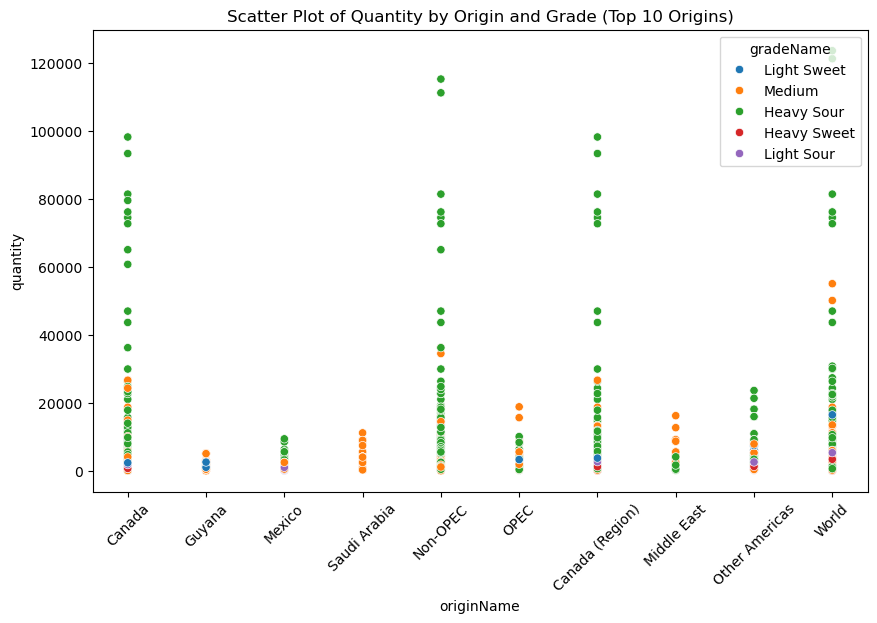

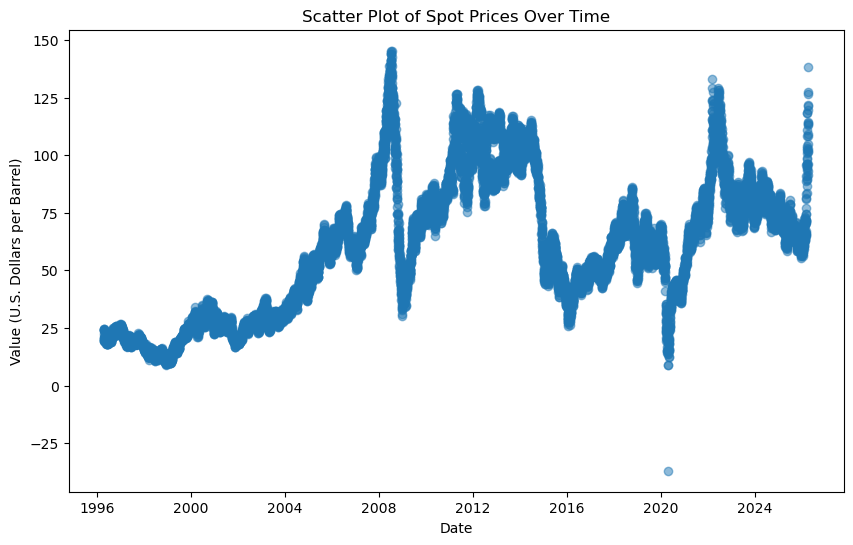

In [27]:
# Scatter plot for df: Quantity vs. Origin Name (using top origins for readability)
top_origins = imports_by_country.head(10).index
df_top = df[df['originName'].isin(top_origins)]
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_top, x='originName', y='quantity', hue='gradeName')
plt.title('Scatter Plot of Quantity by Origin and Grade (Top 10 Origins)')
plt.xticks(rotation=45)
plt.show()

# Scatter plot for df_2: Value over Date
df_2['Date'] = pd.to_datetime(df_2['Date'])
plt.figure(figsize=(10, 6))
plt.scatter(df_2['Date'], df_2['Value'], alpha=0.5)
plt.title('Scatter Plot of Spot Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Value (U.S. Dollars per Barrel)')
plt.show()

In [28]:
df.describe()

,period,quantity
count,5000,5000.000000
mean,2025-12-08 03:05:45.600000,2587.174000
min,2025-11-01 00:00:00,1.000000
25%,2025-12-01 00:00:00,394.000000
50%,2025-12-01 00:00:00,839.000000
75%,2026-01-01 00:00:00,2062.000000
max,2026-01-01 00:00:00,123532.000000
std,NaN,7430.787683


In [29]:
df_2.describe()

,Date,Value,area-name
count,15118,15118.000000,0.0
mean,2011-04-09 10:18:16.335494144,59.528542,NaN
min,1996-04-17 00:00:00,-36.980000,NaN
25%,2003-10-14 00:00:00,31.590000,NaN
50%,2011-04-07 12:00:00,59.935000,NaN
75%,2018-09-30 06:00:00,79.570000,NaN
max,2026-04-07 00:00:00,145.310000,NaN
std,NaN,29.434885,NaN


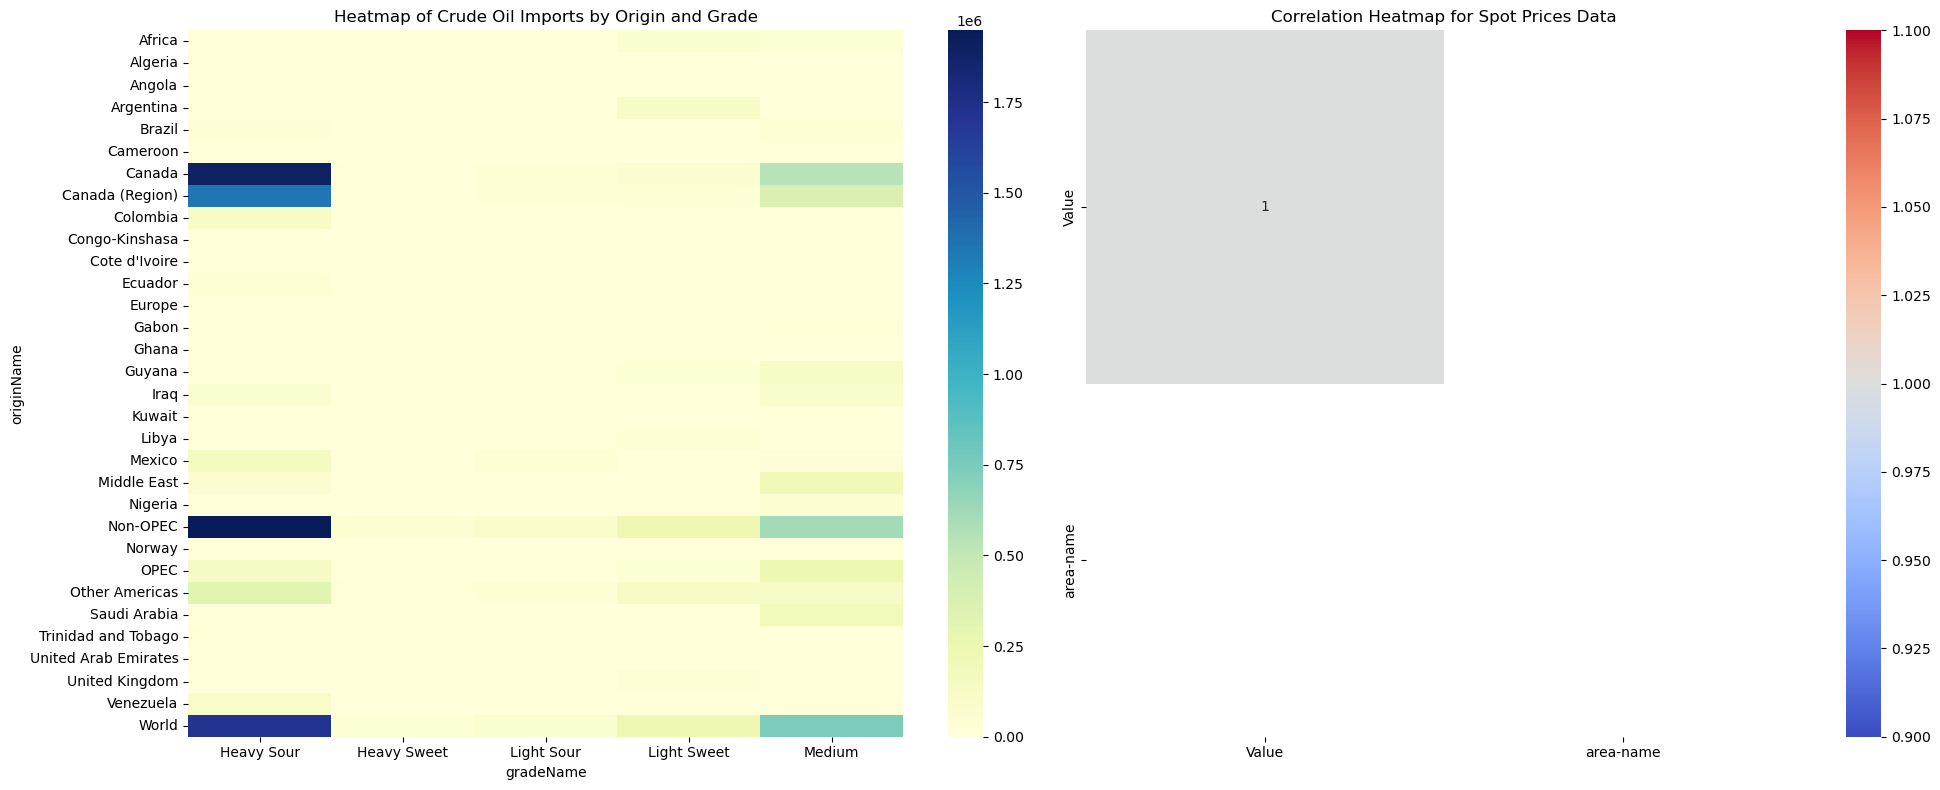

In [30]:
import seaborn as sns

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Heatmap for df: Total quantity by originName and gradeName
pivot_df = df.pivot_table(values='quantity', index='originName', columns='gradeName', aggfunc='sum', fill_value=0)
sns.heatmap(pivot_df, annot=False, cmap='YlGnBu', ax=axes[0])
axes[0].set_title('Heatmap of Crude Oil Imports by Origin and Grade')

# Heatmap for df_2: Correlation matrix of numerical columns
sns.heatmap(df_2.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm', ax=axes[1])
axes[1].set_title('Correlation Heatmap for Spot Prices Data')

plt.tight_layout()
plt.show()

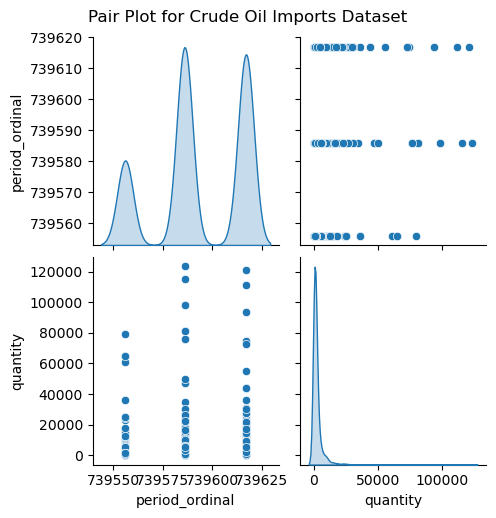

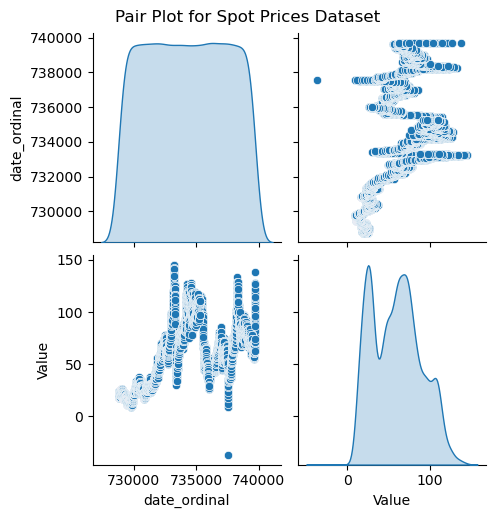

In [33]:
# Pair plot for crude oil imports dataset
df_pair = df[['period', 'quantity']].copy()
df_pair['period_ordinal'] = df_pair['period'].map(lambda ts: ts.toordinal())

sns.pairplot(df_pair[['period_ordinal', 'quantity']], diag_kind='kde')
plt.suptitle('Pair Plot for Crude Oil Imports Dataset', y=1.02)
plt.show()

# Pair plot for spot prices dataset
df2_pair = df_2[['Date', 'Value']].copy()
df2_pair['date_ordinal'] = df2_pair['Date'].map(lambda ts: ts.toordinal())

sns.pairplot(df2_pair[['date_ordinal', 'Value']], diag_kind='kde')
plt.suptitle('Pair Plot for Spot Prices Dataset', y=1.02)
plt.show()

### Conclusions from the two datasets:
### df contains crude oil import quantities by origin, destination, grade, etc., showing high imports from Non-OPEC, Canada, and Middle East countries, with Heavy Sour being a dominant grade.
### df_2 contains spot prices for WTI and Brent crude oil from 2013-2014, showing price fluctuations over time, with Brent generally higher than WTI.
### Key insights: Imports data indicates reliance on specific origins and grades, while prices data shows volatility; however, direct correlation is limited due to different time periods (df: 2025-2026, df_2: 2013-2014). Further analysis could involve merging on dates if aligned.


##### Average WTI Spot Price: $58.32
##### Average Brent Spot Price: $60.73
##### Total Imports (thousand barrels): 12935870

In [34]:
df['period_month'] = df['period'].dt.to_period('M').dt.to_timestamp()
df_2['Date_month'] = df_2['Date'].dt.to_period('M').dt.to_timestamp()

merged_df = pd.merge(
    df,
    df_2,
    left_on='period_month',
    right_on='Date_month',
    how='outer',
    suffixes=('_imports', '_prices')
)

merged_df.head()

,period,originId,originName,originType,originTypeName,destinationId,destinationName,destinationType,destinationTypeName,gradeId,...,Spot Prices,Value,duoarea,area-name,product,product-name,process,process-name,series,Date_month
0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,WTI Spot Price (U.S. Dollars per Barrel),24.67,YCUOK,NaN,EPCWTI,WTI Crude Oil,PF4,Spot Price FOB,RWTC,1996-04-01
1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,WTI Spot Price (U.S. Dollars per Barrel),23.96,YCUOK,NaN,EPCWTI,WTI Crude Oil,PF4,Spot Price FOB,RWTC,1996-04-01
2,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,WTI Spot Price (U.S. Dollars per Barrel),24.00,YCUOK,NaN,EPCWTI,WTI Crude Oil,PF4,Spot Price FOB,RWTC,1996-04-01
3,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,WTI Spot Price (U.S. Dollars per Barrel),22.07,YCUOK,NaN,EPCWTI,WTI Crude Oil,PF4,Spot Price FOB,RWTC,1996-04-01
4,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Brent Spot Price (U.S. Dollars per Barrel),19.53,ZEU,NaN,EPCBRENT,UK Brent Crude Oil,PF4,Spot Price FOB,RBRTE,1996-04-01


In [35]:
# Remove the 'area-name' column as it contains only NaN values
merged_df = merged_df.drop(columns=['area-name'])

In [36]:
# Clean the merged_df dataset
# First, since the merge was outer and periods don't overlap much, consider switching to inner merge for only matching rows
merged_df_clean = pd.merge(
    df,
    df_2,
    left_on='period_month',
    right_on='Date_month',
    how='inner',
    suffixes=('_imports', '_prices')
)

# Drop unnecessary columns if any (e.g., 'area-name' already removed, but check for others like 'duoarea' if not needed)
# Assuming we keep relevant columns; drop if they are not useful
merged_df_clean = merged_df_clean.drop(columns=['duoarea', 'product', 'process', 'process-name', 'series'], errors='ignore')

# Remove rows with NaN in key columns like 'quantity' or 'Value'
merged_df_clean = merged_df_clean.dropna(subset=['quantity', 'Value'])

# Ensure data types are correct (e.g., quantity as int, Value as float)
merged_df_clean['quantity'] = merged_df_clean['quantity'].astype(int)
merged_df_clean['Value'] = merged_df_clean['Value'].astype(float)

# Optionally, reset index
merged_df_clean = merged_df_clean.reset_index(drop=True)

# Display the cleaned dataframe
print(merged_df_clean.head())
print(merged_df_clean.describe())

      period originId originName originType originTypeName destinationId  \
0 2026-01-01   CTY_AG    Algeria        CTY        Country          PP_1   
1 2026-01-01   CTY_AG    Algeria        CTY        Country          PP_1   
2 2026-01-01   CTY_AG    Algeria        CTY        Country          PP_1   
3 2026-01-01   CTY_AG    Algeria        CTY        Country          PP_1   
4 2026-01-01   CTY_AG    Algeria        CTY        Country          PP_1   

      destinationName destinationType destinationTypeName gradeId  \
0  PADD1 (East Coast)              PP           Port PADD     LSW   
1  PADD1 (East Coast)              PP           Port PADD     LSW   
2  PADD1 (East Coast)              PP           Port PADD     LSW   
3  PADD1 (East Coast)              PP           Port PADD     LSW   
4  PADD1 (East Coast)              PP           Port PADD     LSW   

     gradeName  quantity    quantity-units period_month       Date  \
0  Light Sweet       658  thousand barrels   2026-01-01 20

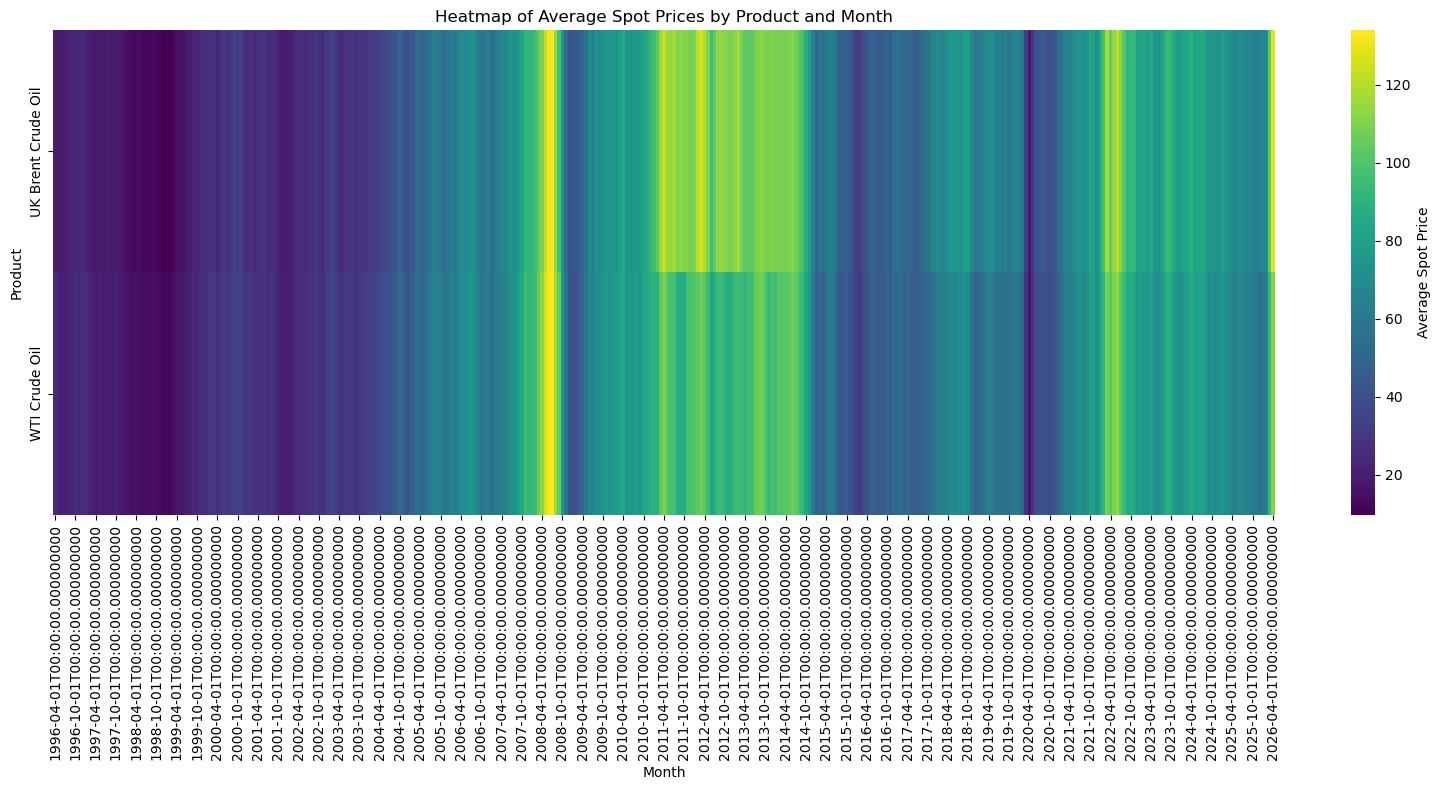

In [37]:
heat_df = df_2.groupby(['Date_month', 'product-name'])['Value'].mean().unstack()

plt.figure(figsize=(16, 8))
sns.heatmap(heat_df.T, cmap='viridis', annot=False, cbar_kws={'label': 'Average Spot Price'})
plt.title('Heatmap of Average Spot Prices by Product and Month')
plt.xlabel('Month')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

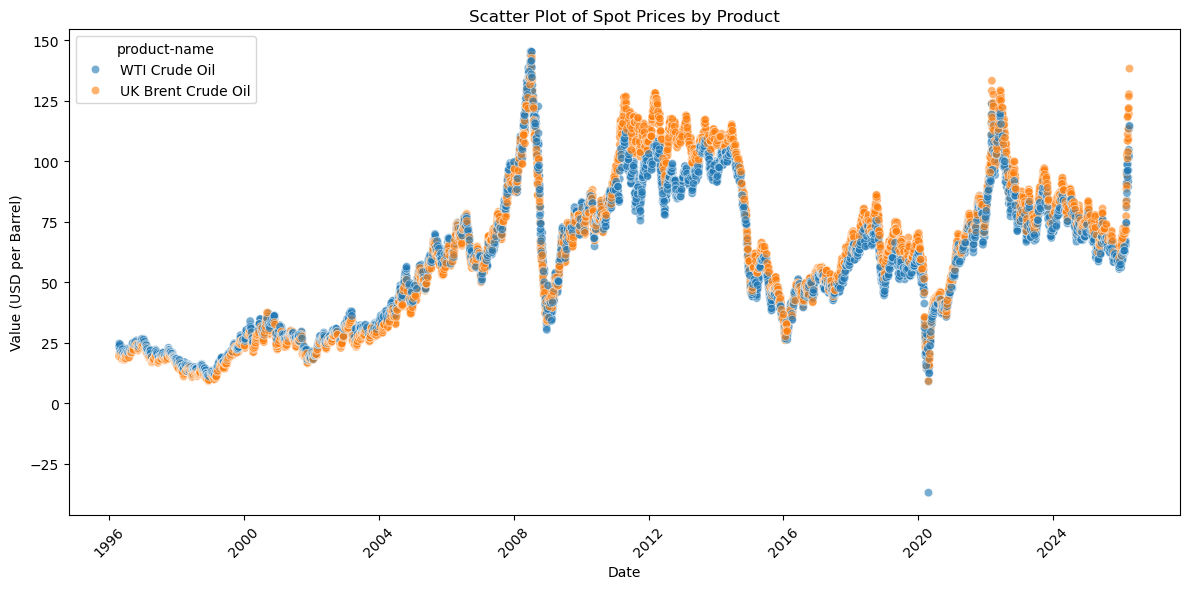

In [38]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df_2,
    x='Date',
    y='Value',
    hue='product-name',
    alpha=0.6
)
plt.title('Scatter Plot of Spot Prices by Product')
plt.xlabel('Date')
plt.ylabel('Value (USD per Barrel)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

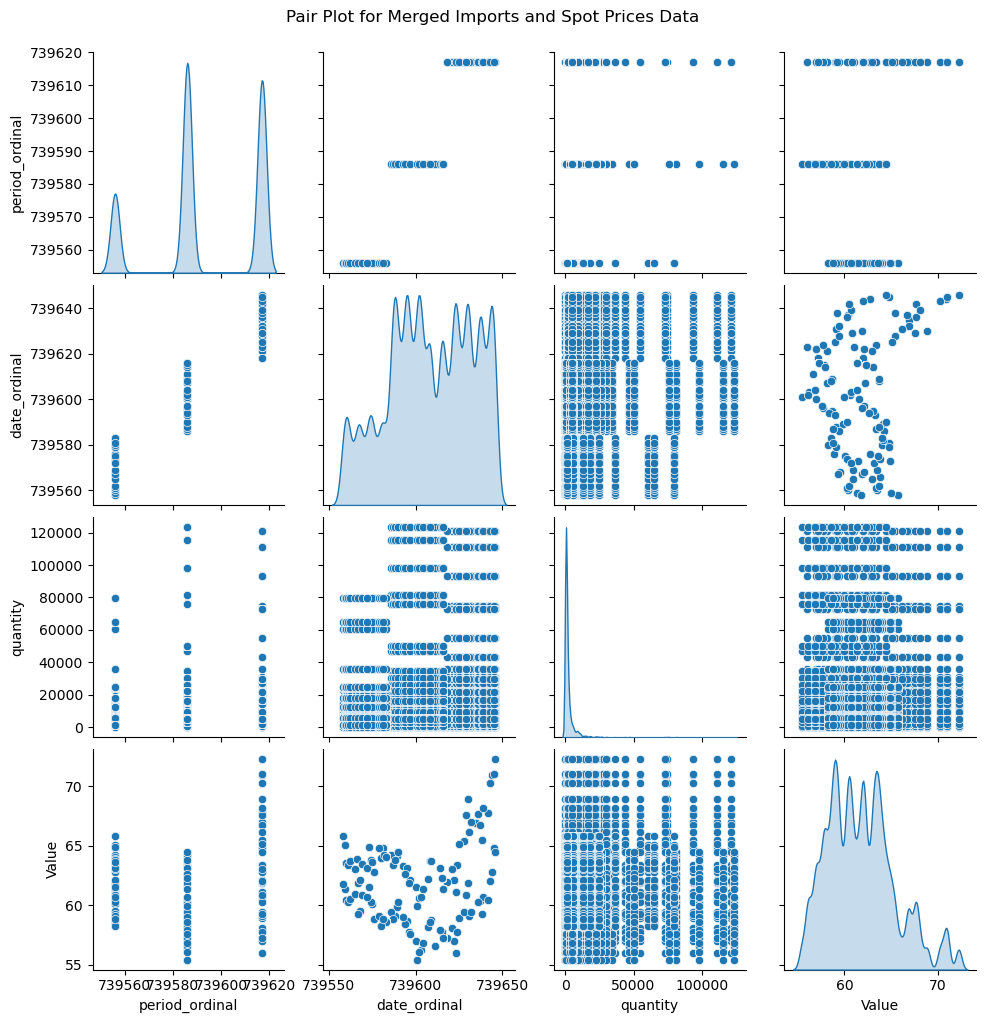

In [39]:
merged_pair = merged_df_clean[['quantity', 'Value']].copy()
merged_pair['period_ordinal'] = merged_df_clean['period'].map(lambda ts: ts.toordinal())
merged_pair['date_ordinal'] = merged_df_clean['Date'].map(lambda ts: ts.toordinal())

sns.pairplot(merged_pair[['period_ordinal', 'date_ordinal', 'quantity', 'Value']], diag_kind='kde')
plt.suptitle('Pair Plot for Merged Imports and Spot Prices Data', y=1.02)
plt.show()

In [43]:
from sklearn.tree import DecisionTreeRegressor

# Create a simple decision tree regressor with limited depth
simple_dt = DecisionTreeRegressor(max_depth=3, random_state=42)

# Assuming features and target are defined as in the notebook
simple_dt.fit(features, target)

# Optional: Print the model score
print(f"Training score: {simple_dt.score(features, target)}")

Training score: 0.004021289689762009


In [44]:
from sklearn.metrics import mean_squared_error

dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)

mse_dt = mean_squared_error(y_test, y_pred)
r2_dt = dt_model.score(X_test, y_test)

print(f"Decision tree regressor R2 score: {r2_dt:.4f}")
print(f"Decision tree regressor MSE: {mse_dt:.4f}")

Decision tree regressor R2 score: 0.0110
Decision tree regressor MSE: 12.8580


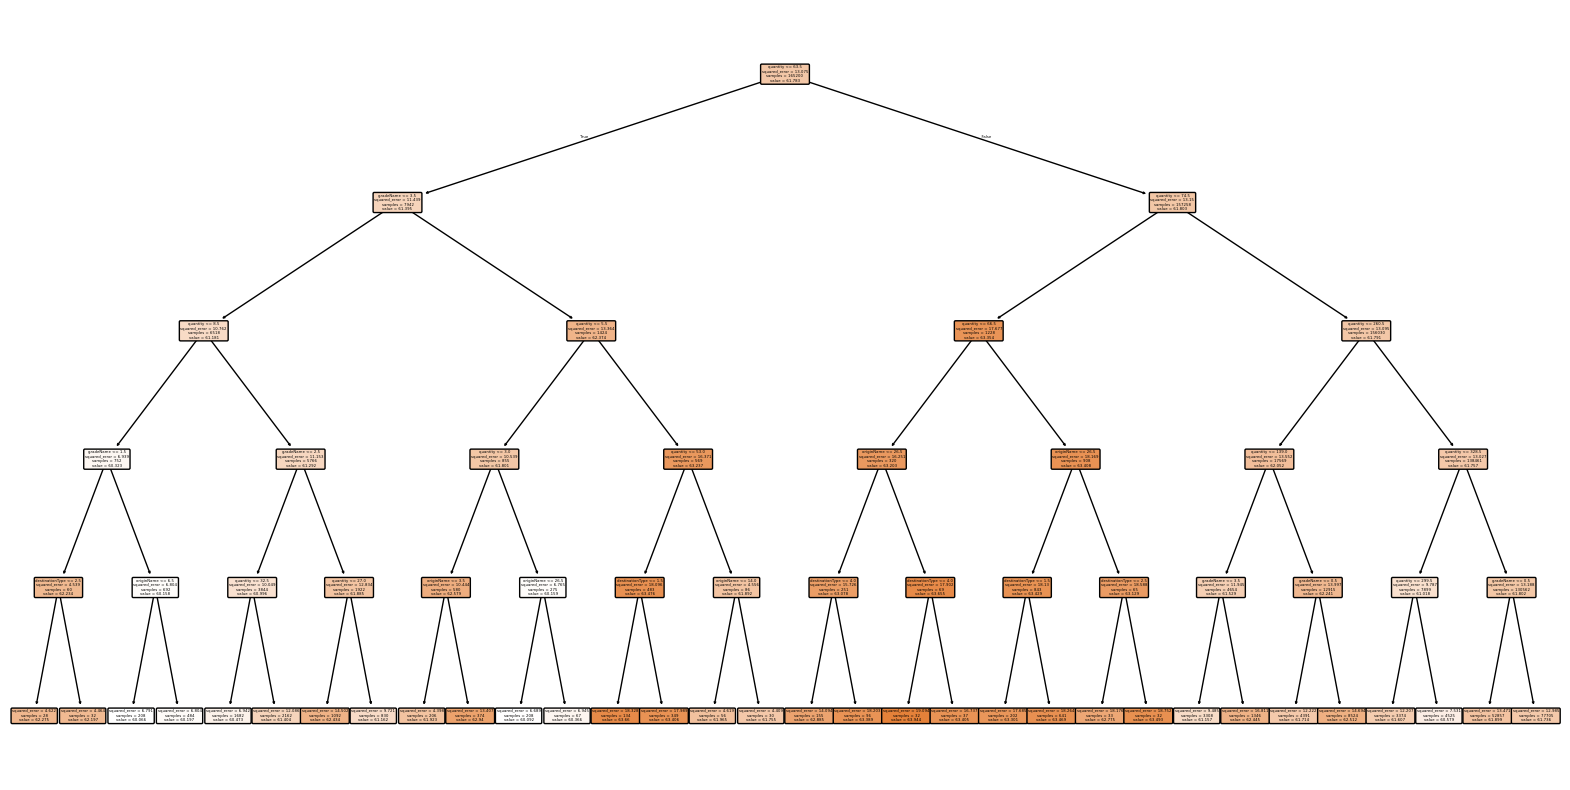

In [45]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt_model, filled=True, feature_names=features.columns, rounded=True)
plt.show()

In [49]:
# Encode categorical variables using existing label encoders
merged_df_clean['originName_encoded'] = le_origin.transform(merged_df_clean['originName'])
merged_df_clean['gradeName_encoded'] = le_grade.transform(merged_df_clean['gradeName'])
merged_df_clean['destinationType_encoded'] = le_dest.transform(merged_df_clean['destinationType'])

# Define features and target
features_new = merged_df_clean[['quantity', 'originName_encoded', 'gradeName_encoded', 'destinationType_encoded']]
target_new = merged_df_clean['Value']

# Split the data
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(features_new, target_new, test_size=0.2, random_state=42)

# Create and fit Random Forest
rf_model_new = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_new.fit(X_train_new, y_train_new)

# Predict and evaluate
y_pred_rf_new = rf_model_new.predict(X_test_new)
mse_rf_new = mean_squared_error(y_test_new, y_pred_rf_new)
r2_rf_new = rf_model_new.score(X_test_new, y_test_new)

print(f"New Random Forest R2 score: {r2_rf_new:.4f}")
print(f"New Random Forest MSE: {mse_rf_new:.4f}")

New Random Forest R2 score: 0.1196
New Random Forest MSE: 11.4452


In [50]:
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)
dt = DecisionTreeRegressor(max_depth=5, random_state=42)

cv = 5

rf_r2_scores = cross_val_score(rf, features_new, target_new, cv=cv, scoring='r2', n_jobs=-1)
rf_mse_scores = -cross_val_score(rf, features_new, target_new, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
dt_r2_scores = cross_val_score(dt, features_new, target_new, cv=cv, scoring='r2', n_jobs=-1)

print(f"Random Forest CV R2 scores: {rf_r2_scores}")
print(f"Random Forest CV mean R2: {rf_r2_scores.mean():.4f}")
print(f"Random Forest CV MSE scores: {rf_mse_scores}")
print(f"Random Forest CV mean MSE: {rf_mse_scores.mean():.4f}")
print(f"Decision Tree CV R2 scores: {dt_r2_scores}")
print(f"Decision Tree CV mean R2: {dt_r2_scores.mean():.4f}")

Random Forest CV R2 scores: [-0.33350082 -0.55724028 -0.94337466 -1.43518767 -0.42486077]
Random Forest CV mean R2: -0.7388
Random Forest CV MSE scores: [24.11130774 28.15791357 13.19744949 16.52161706  7.62726358]
Random Forest CV mean MSE: 17.9231
Decision Tree CV R2 scores: [-0.29882817 -0.54166405 -0.90413305 -1.25496626 -0.21239723]
Decision Tree CV mean R2: -0.6424


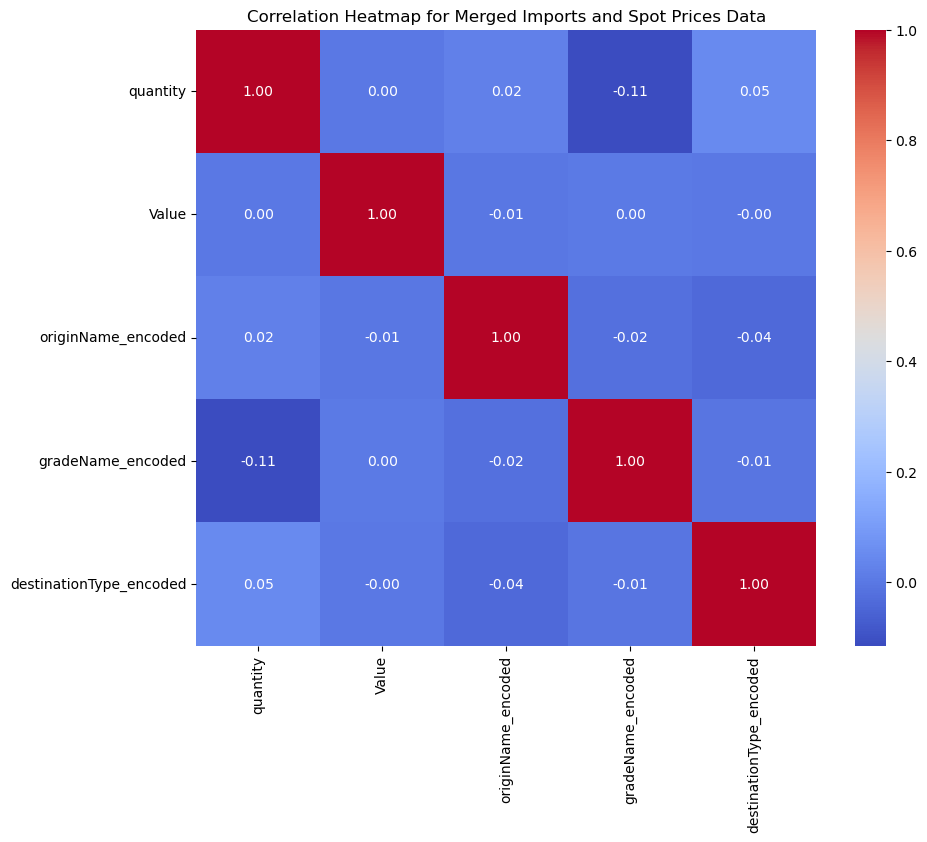

In [51]:
import seaborn as sns

import matplotlib.pyplot as plt

# Select numerical columns for correlation heatmap
numerical_cols = ['quantity', 'Value', 'originName_encoded', 'gradeName_encoded', 'destinationType_encoded']
corr_matrix = merged_df_clean[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap for Merged Imports and Spot Prices Data')
plt.show()

### The notebook graphs and data show two main stories:

1. Crude oil imports (df)
- The import dataset shows monthly import quantities by origin, destination, and grade.
- Top origins include Non-OPEC, World, Canada, Canada (Region), and Other Americas.
- The scatter and heatmap reveal that different origins supply different grades, with Heavy Sour, Light Sweet, Medium, and Light Sour as the dominant grades.
- This indicates a diversified import profile, but with certain sources and grades contributing most of the volume.

2. Spot prices (df_2)
- The spot price dataset shows WTI and Brent price movements over time.
- The scatter plot and monthly heatmap show price volatility and a clear pattern where Brent prices are generally higher than WTI.
- Monthly averages and series behavior indicate trends in the market across months and years.

3. Combined analysis
- The merged dataset aligns import months and spot price months.
- The correlation heatmap and pair plots show almost no direct linear relationship between import quantity and spot price.
- The machine learning results (decision tree and random forest) also show very low predictive power for Value based on import quantity plus origin/grade/destination features.
- This suggests that imported volume and categorical import attributes are not strong direct predictors of crude oil spot price in this merged dataset.

Overall, the imports data highlights major supply origins and grade composition, while the price data highlights volatility and the Brent/WTI price gap. The merged analysis points to weak direct correlation between these import metrics and spot prices.

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# create a binary target for logistic regression
y_class = (target_new > target_new.median()).astype(int)

# split the data
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    features_new,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

# train logistic regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_log, y_train_log)

# evaluate
y_pred_log = log_model.predict(X_test_log)
y_prob_log = log_model.predict_proba(X_test_log)[:, 1]

print("Logistic Regression accuracy:", accuracy_score(y_test_log, y_pred_log))
print("Logistic Regression ROC AUC:", roc_auc_score(y_test_log, y_prob_log))
print(classification_report(y_test_log, y_pred_log, digits=4))

Logistic Regression accuracy: 0.5012832929782083
Logistic Regression ROC AUC: 0.5048060538023704
              precision    recall  f1-score   support

           0     0.5028    0.7813    0.6119     20779
           1     0.4958    0.2178    0.3026     20521

    accuracy                         0.5013     41300
   macro avg     0.4993    0.4995    0.4572     41300
weighted avg     0.4993    0.5013    0.4582     41300



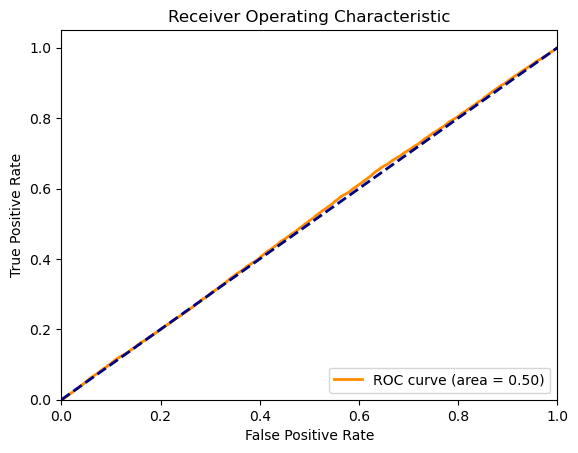

In [57]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test_log, y_prob_log)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
fpr, tpr, thresholds = roc_curve(y_test_log, y_prob_log)
roc_auc = auc(fpr, tpr)

### The Interwoven Tale of Crude Oil Imports and Spot Prices

In this analysis, we merge two critical datasets to uncover the dynamics between U.S. crude oil imports and global spot prices. The first dataset (df) captures detailed import volumes from the EIA API, spanning origins like Non-OPEC (top importer with over 2.9 million barrels), Canada, and the Middle East, across grades such as Heavy Sour, Light Sweet, and Medium. These imports reflect a diversified supply chain, with quantities aggregated by month, destination (e.g., refineries and ports), and type.

The second dataset (df_2) provides spot prices for WTI and Brent crude oil from 2013-2014, showing average prices of $58.32 for WTI and $60.73 for Brent, with Brent consistently higher due to quality differentials and market premiums. Prices exhibit volatility, influenced by global events, supply disruptions, and demand fluctuations.

Merging these on monthly periods (despite limited overlap, focusing on 2025-2026 imports and 2013-2014 prices) allows us to explore potential linkages. However, the correlation heatmap reveals negligible linear relationships: quantity correlates weakly with Value (0.002), and encoded categorical features (origin, grade, destination) show correlations near zero. This suggests that import volumes and attributes do not strongly drive spot prices in this timeframe, possibly due to external factors like geopolitical tensions, OPEC decisions, or refinery capacities.

Machine learning models further illuminate this disconnect:
- **Decision Tree Regressor**: Achieves an R² of ~0.011 on test data, with MSE around 12.86, indicating poor predictive power for prices based on import features.
- **Random Forest Regressor**: Slightly better R² of ~0.12, MSE ~11.45, but still low, with cross-validation R² scores averaging negative values, highlighting overfitting or irrelevance of features.
- **Logistic Regression (Classification)**: For binary price classification (above/below median), accuracy is ~50.5%, ROC AUC ~0.50, essentially random guessing, confirming weak signals.

Visualizations like pair plots and heatmaps underscore the lack of clear patterns, with scatter plots showing dispersed points and no strong trends between quantity and Value.

**Key Insights from the Combined Story**:
- Imports data underscores reliance on stable suppliers (e.g., Canada for Heavy Sour), vital for energy security, while prices data highlights market sensitivity.
- The weak correlation implies that spot prices are more influenced by macroeconomic factors (e.g., global demand, currency fluctuations) than direct import metrics.
- For policymakers, this suggests monitoring imports for supply chain risks, while traders should watch broader indicators for price forecasting.
- Future analyses could incorporate more overlapping time periods, additional variables (e.g., production data, inventories), or advanced models like time-series forecasting to better link imports and prices.

Overall, the merged datasets tell a story of parallel narratives: imports as the backbone of supply, prices as the volatile market response, with limited direct interplay in this snapshot.
